In [72]:
import matplotlib
import datetime as dt
matplotlib.__version__
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv('sales_data.csv')

In [55]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   str    
 2   Sales_Rep             1000 non-null   str    
 3   Region                1000 non-null   str    
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   str    
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   str    
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   str    
 12  Sales_Channel         1000 non-null   str    
 13  Region_and_Sales_Rep  1000 non-null   str    
dtypes: float64(4), int64(2), str(8)
memory usage: 109.5 KB


In [56]:
data.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [57]:
# first step understand the data
data.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


In [58]:
data.nunique()

Product_ID               100
Sale_Date                340
Sales_Rep                  5
Region                     4
Sales_Amount             998
Quantity_Sold             49
Product_Category           4
Unit_Cost                998
Unit_Price              1000
Customer_Type              2
Discount                  31
Payment_Method             3
Sales_Channel              2
Region_and_Sales_Rep      20
dtype: int64

Sales Per Region

In [59]:
data['Sale_Date'] = pd.to_datetime(data['Sale_Date'])

In [60]:
data['Sale_Date'].dtype

dtype('<M8[us]')

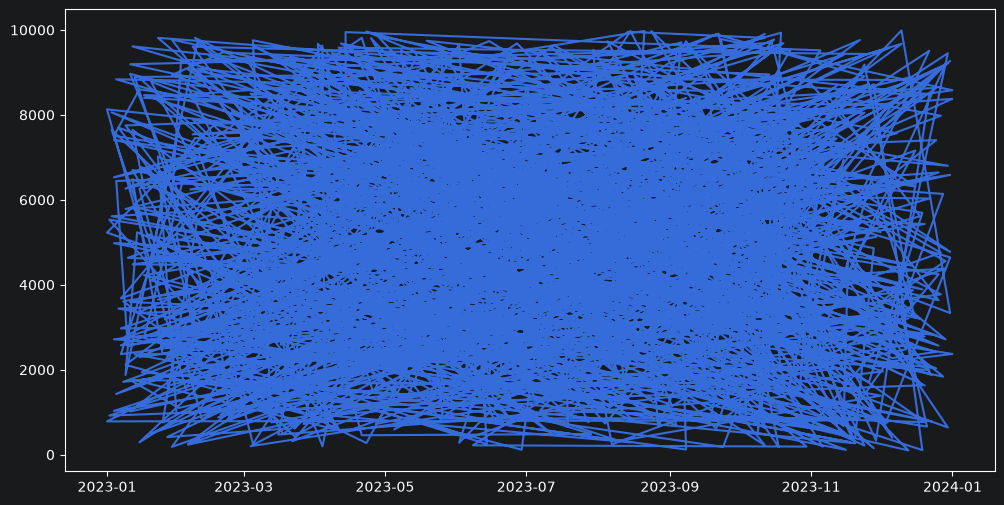

In [61]:
# Line Chart
plt.figure(figsize=(12,6))
plt.plot(data['Sale_Date'], data['Sales_Amount'])
plt.show()

In [62]:
trend = data.groupby('Sale_Date')['Sales_Amount'].sum().reset_index()

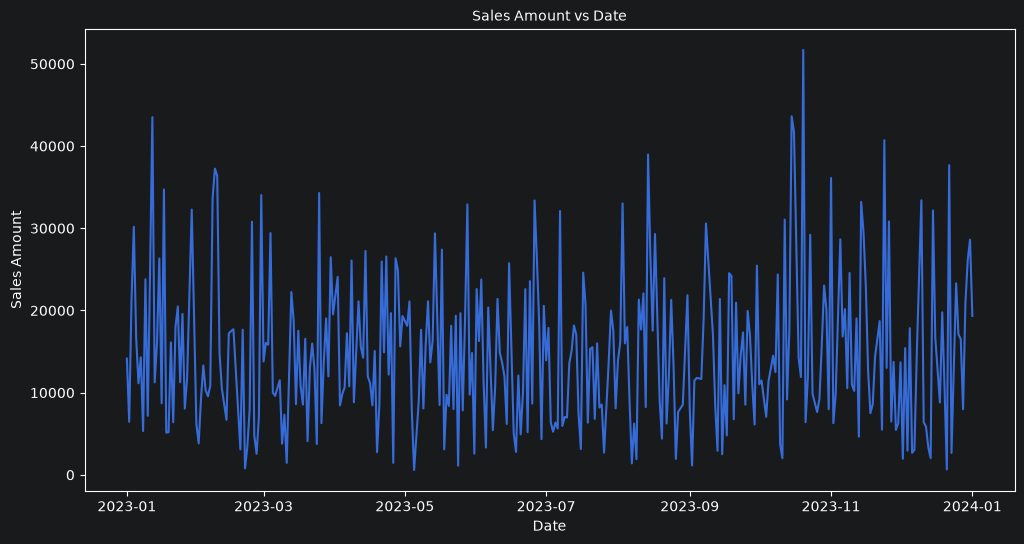

In [63]:
# Line Chart
plt.figure(figsize=(12,6))
plt.plot(trend['Sale_Date'], trend['Sales_Amount'])
plt.title('Sales Amount vs Date', fontsize=10)
plt.xlabel('Date', fontsize=10)
plt.ylabel('Sales Amount', fontsize=10)
plt.show()

Sales Per Region

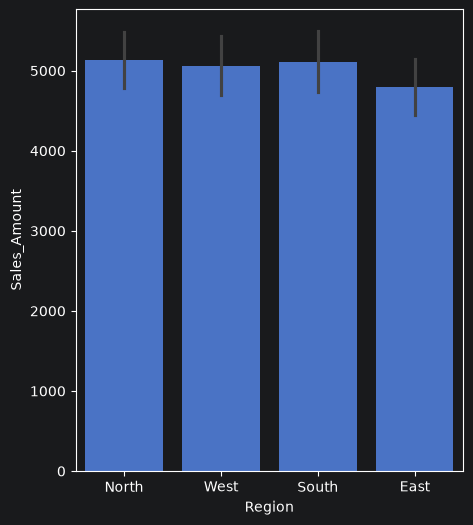

In [64]:
# Bar Graph plt.bar & sns.barplot
plt.figure(figsize=(5,6))
sns.barplot(data, x='Region', y='Sales_Amount')
plt.show()

In [65]:
region_sales = data.groupby('Region')['Sales_Amount'].sum().sort_values().reset_index()

In [66]:
region_sales

,Region,Sales_Amount
0,South,1154250.86
1,West,1235608.93
2,East,1259792.93
3,North,1369612.51


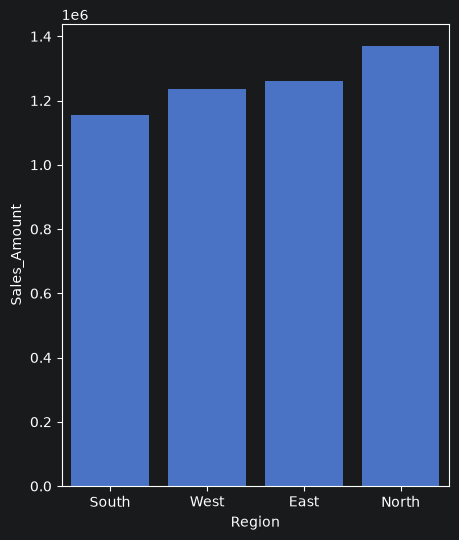

In [67]:
plt.figure(figsize=(5,6))
sns.barplot(region_sales, x='Region', y='Sales_Amount')
plt.show()

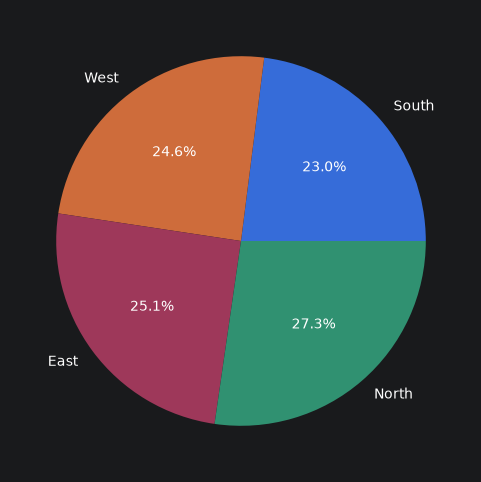

In [68]:
# Pie Chart
plt.figure(figsize=(6,6))
plt.pie(x=region_sales['Sales_Amount'], labels=region_sales['Region'], autopct='%1.1f%%')
plt.show()

TypeError: cannot unpack non-iterable Axes object

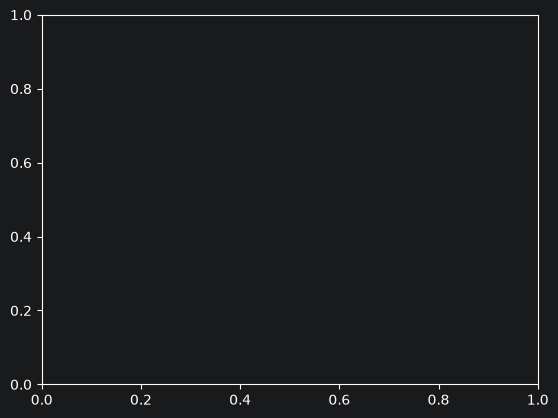

In [69]:
fig, ax = plt.subplot()
ax.pie(x=region_sales['Sales_Amount'], y=region_sales['Region'], autopct='%1.1f%%')
plt.show()

In [ ]:
matplotlib.__version__

Distributions

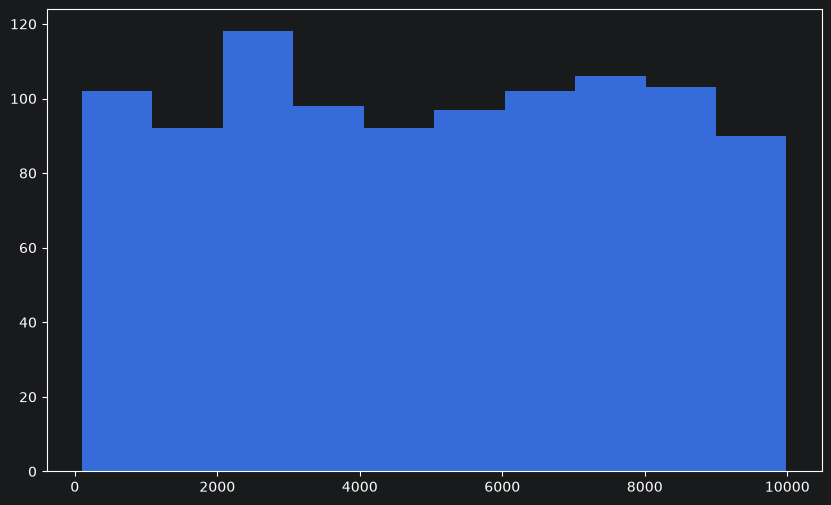

In [74]:
plt.figure(figsize=(10,6))
plt.hist(data['Sales_Amount'])
plt.show()

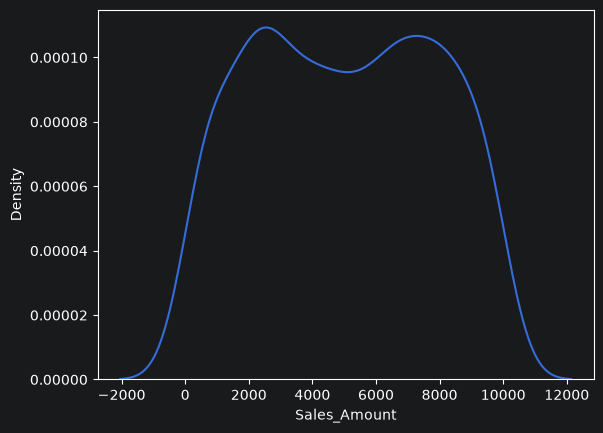

In [75]:
sns.kdeplot(data['Sales_Amount'])
plt.show()

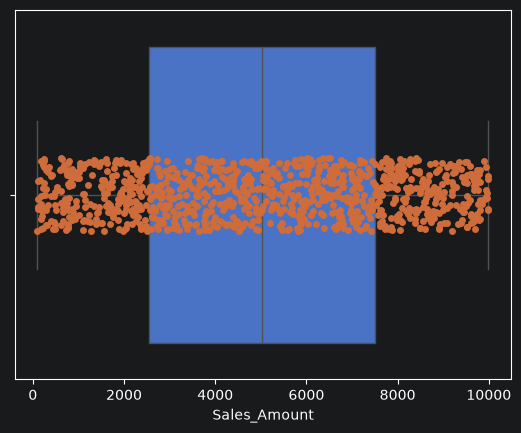

In [78]:
sns.boxplot(data['Sales_Amount'], orient='h')
sns.stripplot(data=data, x='Sales_Amount')
plt.show()

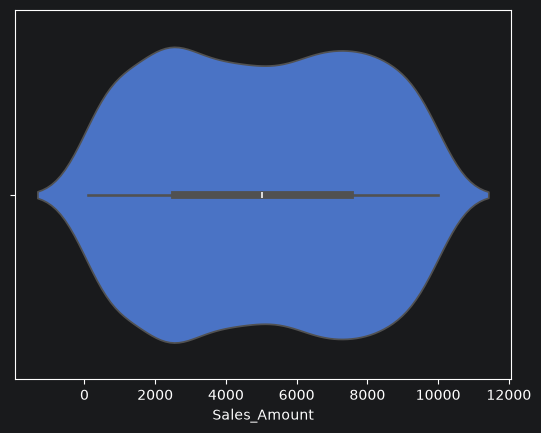

In [77]:
sns.violinplot(data['Sales_Amount'], orient='h')
plt.show()